# 01 Data Cleaning
This notebook validates, cleans, and prepares the synthetic Defense Logistics datasets for SQL, EDA, Machine Learning, and Power BI.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"]=(8,4)


## 2. Load Datasets

In [2]:
bases = pd.read_csv("../data/raw/bases.csv")
equipment = pd.read_csv("../data/raw/equipment.csv")
inventory = pd.read_csv("../data/raw/inventory.csv")
fuel = pd.read_csv("../data/raw/fuel_logs.csv")
maintenance = pd.read_csv("../data/raw/maintenance.csv")
missions = pd.read_csv("../data/raw/missions.csv")
suppliers = pd.read_csv("../data/raw/suppliers.csv")

datasets = {
    "Bases": bases,
    "Equipment": equipment,
    "Inventory": inventory,
    "Fuel Logs": fuel,
    "Maintenance": maintenance,
    "Missions": missions,
    "Suppliers": suppliers
}


## 3. Dataset Overview

In [3]:
for name, df in datasets.items():
    print("="*60)
    print(name)
    print(df.shape)
    display(df.head())


Bases
(30, 7)


,Base_ID,Base_Name,Region,Latitude,Longitude,Personnel,Mission_Type
0,B001,Alpha Base,Central,23.2494,69.3206,4060,Disaster Relief
1,B002,Bravo Base,North,15.4245,83.1469,908,Training
2,B003,Charlie Base,East,34.6757,70.1945,1706,Reconnaissance
3,B004,Delta Base,East,24.4774,79.4830,4322,Logistics
4,B005,Echo Base,East,19.7449,86.5009,2859,Logistics


Equipment
(5000, 8)


,Equipment_ID,Supplier_ID,Equipment_Name,Category,Manufacturer,Purchase_Year,Expected_Life,Status
0,EQ00001,SUP0047,Drone,Drone,Ashok Leyland Defence,2018,25,Operational
1,EQ00002,SUP0119,Drone,Drone,HAL,2017,12,Operational
2,EQ00003,SUP0065,Radar,Radar,Mahindra Defence,2021,29,Operational
3,EQ00004,SUP0291,Armored Vehicle,Armored Vehicle,Bharat Dynamics,2020,27,Operational
4,EQ00005,SUP0143,Drone,Drone,Bharat Dynamics,2022,18,Operational


Inventory
(100000, 7)


...

,Maintenance_ID,Equipment_ID,Base_ID,Maintenance_Date,Maintenance_Type,Downtime_Days,Maintenance_Cost_INR,Technician_Team,Failure
0,M000001,EQ02153,B018,2025-06-04,Corrective,3,91775.06,Team Alpha,No
1,M000002,EQ03022,B012,2025-03-23,Emergency,4,141636.08,Team Bravo,No
2,M000003,EQ00559,B001,2025-05-18,Preventive,4,199273.66,Team Charlie,No
3,M000004,EQ04824,B019,2026-12-15,Preventive,11,310265.43,Team Alpha,Yes
4,M000005,EQ01091,B003,2026-10-07,Emergency,4,78415.41,Team Delta,No


Missions
(20000, 11)


,Mission_ID,Mission_Date,Base_ID,Region,Mission_Type,Priority,Weather,Duration_Hours,Personnel_Deployed,Budget_INR,Mission_Status
0,MIS000001,2026-02-25,B029,South,Training Exercise,Medium,Rain,47,219,327896.69,Completed
1,MIS000002,2026-10-11,B003,East,Medical Support,High,Fog,7,251,3988362.22,Completed
2,MIS000003,2025-09-27,B021,South,Supply Delivery,Medium,Snow,26,238,1458388.69,Completed
3,MIS000004,2025-12-15,B029,South,Supply Delivery,Medium,Rain,20,269,4877935.24,Completed
4,MIS000005,2025-01-10,B030,East,Disaster Relief,Critical,Rain,69,366,3595196.87,Completed


Suppliers
(300, 9)


,Supplier_ID,Supplier_Name,City,Equipment_Category,Years_Experience,Annual_Contract_Value_INR,Average_Delivery_Days,Quality_Rating,On_Time_Delivery_Percentage
0,SUP0001,Skyline Technologies 1,Chennai,Vehicles,38,1.118373e+08,23,4.5,90.0
1,SUP0002,Bravo Engineering 2,Chennai,Drones,24,4.334872e+08,19,3.2,92.4
2,SUP0003,Prime Defense Systems 3,Bengaluru,Engineering Equipment,34,1.119134e+08,23,3.0,86.8
3,SUP0004,Pioneer Equipment 4,Kolkata,Vehicles,23,4.703304e+08,29,3.5,91.3
4,SUP0005,Alpha Logistics 5,Lucknow,Engineering Equipment,16,2.195658e+08,23,3.5,86.9


## 4. Data Types

In [4]:
for name, df in datasets.items():
    print("\n", name)
    print(df.dtypes)



 Bases
Base_ID             str
Base_Name           str
Region              str
Latitude        float64
Longitude       float64
Personnel         int64
Mission_Type        str
dtype: object

 Equipment
Equipment_ID        str
Supplier_ID         str
Equipment_Name      str
Category            str
Manufacturer        str
Purchase_Year     int64
Expected_Life     int64
Status              str
dtype: object

 Inventory
Inventory_ID          str
Base_ID               str
Equipment_ID          str
Quantity            int64
Available           int64
Reorder_Level       int64
Inventory_Status      str
dtype: object

 Fuel Logs
Fuel_ID                     str
Date                        str
Base_ID                     str
Region                      str
Vehicle_Type                str
Fuel_Consumed_Liters    float64
Fuel_Cost_INR           float64
dtype: object

 Maintenance
Maintenance_ID              str
Equipment_ID                str
Base_ID                     str
Maintenance_Date        

## 5. Missing Values

In [5]:
missing_summary = {}
for name, df in datasets.items():
    missing_summary[name] = df.isnull().sum()
    print("\n", name)
    print(df.isnull().sum())



 Bases
Base_ID         0
Base_Name       0
Region          0
Latitude        0
Longitude       0
Personnel       0
Mission_Type    0
dtype: int64

 Equipment
Equipment_ID      0
Supplier_ID       0
Equipment_Name    0
Category          0
Manufacturer      0
Purchase_Year     0
Expected_Life     0
Status            0
dtype: int64

 Inventory
Inventory_ID        0
Base_ID             0
Equipment_ID        0
Quantity            0
Available           0
Reorder_Level       0
Inventory_Status    0
dtype: int64

 Fuel Logs
Fuel_ID                 0
Date                    0
Base_ID                 0
Region                  0
Vehicle_Type            0
Fuel_Consumed_Liters    0
Fuel_Cost_INR           0
dtype: int64

 Maintenance
Maintenance_ID          0
Equipment_ID            0
Base_ID                 0
Maintenance_Date        0
Maintenance_Type        0
Downtime_Days           0
Maintenance_Cost_INR    0
Technician_Team         0
Failure                 0
dtype: int64

 Missions
Mission_ID

## 6. Duplicate Records

In [6]:
for name, df in datasets.items():
    dup = df.duplicated().sum()
    print(f"{name}: {dup} duplicate rows")


Bases: 0 duplicate rows
Equipment: 0 duplicate rows
Inventory: 0 duplicate rows
Fuel Logs: 0 duplicate rows
Maintenance: 0 duplicate rows
Missions: 0 duplicate rows
Suppliers: 0 duplicate rows


## 7. Clean Data

In [7]:
for name, df in datasets.items():
    df.drop_duplicates(inplace=True)

    obj_cols = df.select_dtypes(include="object").columns
    for col in obj_cols:
        df[col] = df[col].str.strip()

    num_cols = df.select_dtypes(include=["int64","float64"]).columns
    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())

    for col in obj_cols:
        df[col] = df[col].fillna("Unknown")


C:\Users\PRIYANKA DEY\AppData\Local\Temp\ipykernel_5748\80612508.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include="object").columns
C:\Users\PRIYANKA DEY\AppData\Local\Temp\ipykernel_5748\80612508.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user

## 8. Convert Date Columns

In [8]:
fuel["Date"] = pd.to_datetime(fuel["Date"])
maintenance["Maintenance_Date"] = pd.to_datetime(maintenance["Maintenance_Date"])
missions["Mission_Date"] = pd.to_datetime(missions["Mission_Date"])


## 9. Range Validation

In [9]:
fuel = fuel[fuel["Fuel_Consumed_Liters"]>=0]
maintenance = maintenance[maintenance["Maintenance_Cost_INR"]>=0]
inventory = inventory[inventory["Quantity"]>=0]
missions = missions[missions["Budget_INR"]>=0]


## 10. Foreign Key Validation

In [10]:
valid_bases = set(bases["Base_ID"])
valid_equipment = set(equipment["Equipment_ID"])

fuel = fuel[fuel["Base_ID"].isin(valid_bases)]
inventory = inventory[inventory["Base_ID"].isin(valid_bases)]
maintenance = maintenance[maintenance["Base_ID"].isin(valid_bases)]
missions = missions[missions["Base_ID"].isin(valid_bases)]

inventory = inventory[inventory["Equipment_ID"].isin(valid_equipment)]
maintenance = maintenance[maintenance["Equipment_ID"].isin(valid_equipment)]

if "Supplier_ID" in equipment.columns:
    valid_suppliers = set(suppliers["Supplier_ID"])
    equipment = equipment[equipment["Supplier_ID"].isin(valid_suppliers)]


## 11. Feature Engineering

In [11]:
equipment["Equipment_Age"] = 2026 - equipment["Purchase_Year"]

inventory["Inventory_Utilization"] = (
    inventory["Available"]/inventory["Quantity"]
).replace([np.inf,-np.inf],0).fillna(0)

maintenance["Cost_Per_Day"] = (
    maintenance["Maintenance_Cost_INR"]/
    maintenance["Downtime_Days"].replace(0,1)
)

fuel["Fuel_Cost_Per_Liter"] = (
    fuel["Fuel_Cost_INR"]/fuel["Fuel_Consumed_Liters"]
)

missions["Budget_Per_Person"] = (
    missions["Budget_INR"]/missions["Personnel_Deployed"]
)


## 12. Quick Visualizations

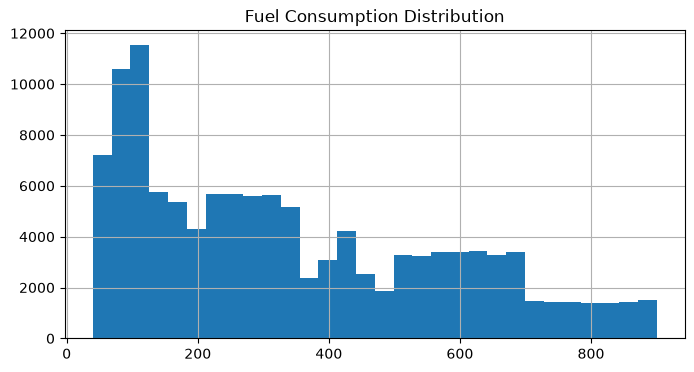

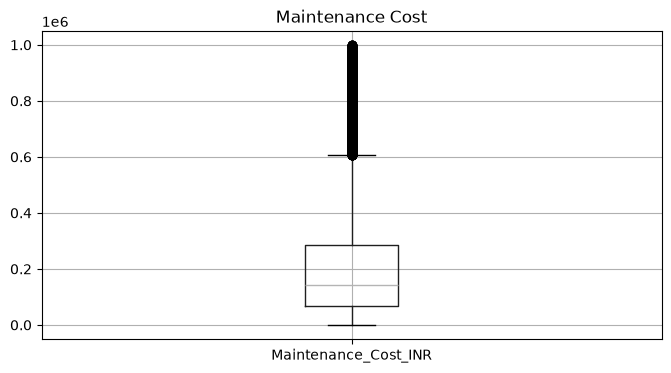

In [12]:
fuel["Fuel_Consumed_Liters"].hist(bins=30)
plt.title("Fuel Consumption Distribution")
plt.show()

maintenance.boxplot(column="Maintenance_Cost_INR")
plt.title("Maintenance Cost")
plt.show()


## 13. Save Cleaned Data

In [13]:
bases.to_csv("../data/processed/bases_clean.csv",index=False)
equipment.to_csv("../data/processed/equipment_clean.csv",index=False)
inventory.to_csv("../data/processed/inventory_clean.csv",index=False)
fuel.to_csv("../data/processed/fuel_logs_clean.csv",index=False)
maintenance.to_csv("../data/processed/maintenance_clean.csv",index=False)
missions.to_csv("../data/processed/missions_clean.csv",index=False)
suppliers.to_csv("../data/processed/suppliers_clean.csv",index=False)

print("Processed datasets saved.")


Processed datasets saved.


## 14. Final Summary

In [14]:
summary = pd.DataFrame({
    "Dataset":[k for k in datasets],
    "Rows":[len(bases),len(equipment),len(inventory),len(fuel),len(maintenance),len(missions),len(suppliers)]
})
display(summary)


,Dataset,Rows
0,Bases,30
1,Equipment,5000
2,Inventory,100000
3,Fuel Logs,120000
4,Maintenance,50000
5,Missions,20000
6,Suppliers,300
